In [ ]:
!pip -q install funasr modelscope kagglehub soundfile librosa scikit-learn matplotlib pandas tqdm

In [ ]:
import kagglehub

path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Dataset path:", path)

In [ ]:
import os
import glob
import pandas as pd

audio_files = glob.glob(os.path.join(path, "**", "*.wav"), recursive=True)

print("Total audio files found:", len(audio_files))
print(audio_files[:5])

In [ ]:
import os
import pandas as pd

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

rows = []

for f in audio_files:
    name = os.path.basename(f)
    parts = name.split("-")

    # RAVDESS format: 03-01-05-01-02-02-12.wav
    # parts[2] = emotion code
    # last part before .wav = actor id
    emotion_code = parts[2]
    speaker_id = parts[-1].split(".")[0]

    rows.append({
        "path": f,
        "filename": name,
        "emotion_code": emotion_code,
        "emotion": emotion_map[emotion_code],
        "emotion_id": int(emotion_code) - 1,   # 0 to 7
        "speaker": speaker_id
    })

df = pd.DataFrame(rows)

print(df.head())
print("\nEmotion counts:")
print(df["emotion"].value_counts().sort_index())
print("\nNumber of speakers:", df["speaker"].nunique())

In [ ]:
from funasr import AutoModel

MODEL_NAME = "iic/emotion2vec_plus_seed"

model = AutoModel(model=MODEL_NAME)

print("Loaded model:", MODEL_NAME)

In [ ]:
import numpy as np

test_path = df.iloc[0]["path"]
print("Testing file:", test_path)

res = model.generate(
    test_path,
    output_dir=None,
    granularity="utterance",
    extract_embedding=True
)

print(type(res))
print(res)

emb = np.array(res[0]["feats"]).reshape(-1)
print("Embedding shape:", emb.shape)

In [ ]:
import numpy as np
from tqdm.auto import tqdm

def extract_embedding(wav_path):
    res = model.generate(
        wav_path,
        output_dir=None,
        granularity="utterance",
        extract_embedding=True
    )
    emb = np.array(res[0]["feats"]).reshape(-1)
    return emb

embeddings = []
failed_files = []

for wav_path in tqdm(df["path"].tolist(), desc="Extracting embeddings"):
    try:
        emb = extract_embedding(wav_path)
        embeddings.append(emb)
    except Exception as e:
        embeddings.append(None)
        failed_files.append((wav_path, str(e)))

print("Done.")
print("Failed files:", len(failed_files))
if len(failed_files) > 0:
    print("First few failures:")
    for item in failed_files[:5]:
        print(item)

Extracting embeddings:   0%|          | 0/2880 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.

100%|██████████| 1/1 [00:01<00:00,  1.65s/it]
{'load_data': '0.054', 'extract_feat': 0.0, 'forward': '1.648', 'batch_size': '1', 'rtf': '0.402'}, : 100%|██████████| 1/1 [00:01<00:00,  1.65s/it]
rtf_avg: 0.402: 100%|██████████| 1/1 [00:01<00:00,  1.67s/it]

100%|██████████| 1/1 [00:01<00:00,  1.98s/it]
{'load_data': '0.054', 'extract_feat': 0.0, 'forward': '1.983', 'batch_size': '1', 'rtf': '0.577'}, : 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]
rtf_avg: 0.577: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it]

100%|██████████| 1/1 [00:02<00:00,  2.23s/it]
{'load_data': '0.057', 'extract_feat': 0.0, 'forward': '2.230', 'batch_size': '1', 'rtf': '0.562'}, : 100%|██████████| 1/1 [00:02<00:00,  2.23s/it]
rtf_avg: 0.562: 100%|██████████| 1/1 [00:02<00:00,  2.24s/it]

100%|██████████| 1/1 [00:01<00:00,  1.53s/it]
{'load_data': '0.069', 'extract_feat': 0.0, 'forward': '1.530', 'batch_size': '1', 'rtf': '0.459'}, : 100%|██████████| 1/1 [00:01<0

Done.
Failed files: 0


In [ ]:
valid_mask = [e is not None for e in embeddings]

df_valid = df.loc[valid_mask].reset_index(drop=True)
X = np.stack([e for e in embeddings if e is not None])
y = df_valid["emotion_id"].values
groups = df_valid["speaker"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of valid samples:", len(df_valid))
print("Number of unique speakers:", len(set(groups)))

X shape: (2880, 768)
y shape: (2880,)
Number of valid samples: 2880
Number of unique speakers: 24


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_speakers = sorted(set(groups[train_idx]))
test_speakers = sorted(set(groups[test_idx]))

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train speakers:", train_speakers)
print("Test speakers:", test_speakers)

Train size: 2280
Test size: 600
Train speakers: ['02', '03', '04', '05', '06', '07', '08', '10', '11', '13', '14', '15', '16', '18', '20', '21', '22', '23', '24']
Test speakers: ['01', '09', '12', '17', '19']


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)

clf.fit(X_train, y_train)

print("Classifier trained.")

Classifier trained.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", round(acc, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Accuracy: 0.8333
Macro F1: 0.8165
Weighted F1: 0.8376


In [ ]:
label_names = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised"
]

report = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

     neutral     0.5625    0.4500    0.5000        40
        calm     0.5614    0.8000    0.6598        80
       happy     0.8947    0.8500    0.8718        80
         sad     0.8205    0.8000    0.8101        80
       angry     1.0000    0.9000    0.9474        80
     fearful     0.9706    0.8250    0.8919        80
     disgust     0.9744    0.9500    0.9620        80
   surprised     0.8780    0.9000    0.8889        80

    accuracy                         0.8333       600
   macro avg     0.8328    0.8094    0.8165       600
weighted avg     0.8508    0.8333    0.8376       600



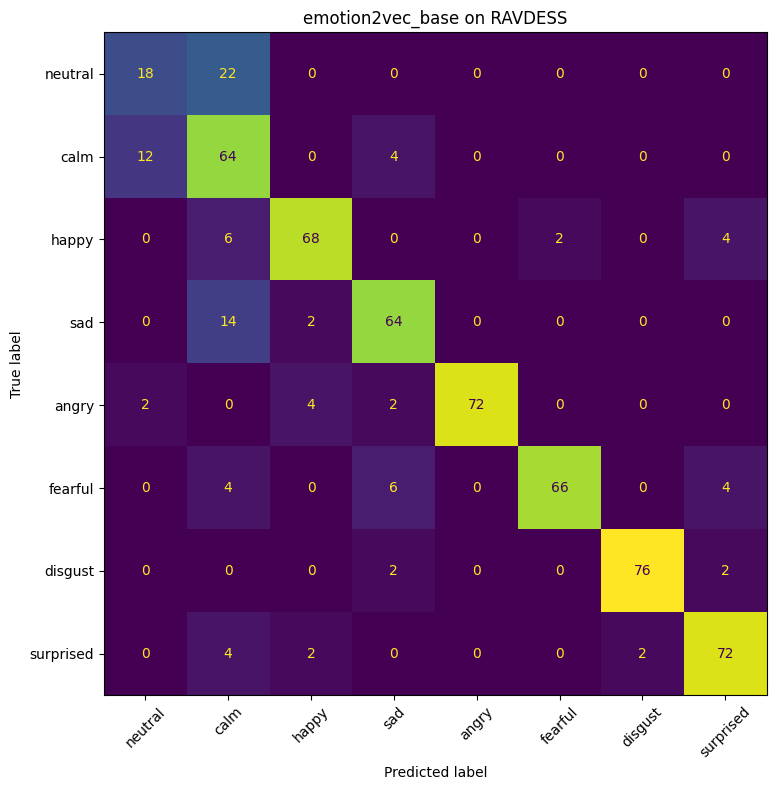

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("emotion2vec_base on RAVDESS")
plt.tight_layout()
plt.show()

In [ ]:
import json
import pandas as pd

results = {
    "model": "iic/emotion2vec_base",
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "num_samples": int(len(df_valid)),
    "num_speakers": int(len(set(groups))),
    "train_speakers": train_speakers,
    "test_speakers": test_speakers
}

with open("/content/emotion2vec_ravdess_results.json", "w") as f:
    json.dump(results, f, indent=2)

report_df = pd.DataFrame(classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    digits=4,
    output_dict=True
)).transpose()

report_df.to_csv("/content/emotion2vec_ravdess_report.csv")

print("Saved files:")
print("/content/emotion2vec_ravdess_results.json")
print("/content/emotion2vec_ravdess_report.csv")

Saved files:
/content/emotion2vec_ravdess_results.json
/content/emotion2vec_ravdess_report.csv


In [ ]:
import pandas as pd

# Summary metrics table
summary_table = pd.DataFrame({
    "Model": ["emotion2vec_base"],
    "Dataset": ["RAVDESS"],
    "Evaluation": ["Speaker-independent split"],
    "Accuracy": [round(acc,4)],
    "Macro F1": [round(macro_f1,4)],
    "Weighted F1": [round(weighted_f1,4)],
    "Total Samples": [len(df_valid)],
    "Speakers": [len(set(groups))]
})

print("=== MODEL PERFORMANCE SUMMARY ===")
display(summary_table)

# Per-class performance table
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    output_dict=True
)

class_table = pd.DataFrame(report_dict).transpose()

print("\n=== PER-CLASS PERFORMANCE ===")
display(class_table)

# Optional: save tables
summary_table.to_csv("/content/emotion2vec_with_seed_summary_table.csv", index=False)
class_table.to_csv("/content/emotion2vec_with_seed_per_class_results.csv")

print("\nSaved:")
print("/content/emotion2vec_with_seed_summary_table.csv")
print("/content/emotion2vec_with_seed_per_class_results.csv")

=== MODEL PERFORMANCE SUMMARY ===


,Model,Dataset,Evaluation,Accuracy,Macro F1,Weighted F1,Total Samples,Speakers
0,emotion2vec_base,RAVDESS,Speaker-independent split,0.8333,0.8165,0.8376,2880,24



=== PER-CLASS PERFORMANCE ===


,precision,recall,f1-score,support
neutral,0.562500,0.450000,0.500000,40.000000
calm,0.561404,0.800000,0.659794,80.000000
happy,0.894737,0.850000,0.871795,80.000000
sad,0.820513,0.800000,0.810127,80.000000
angry,1.000000,0.900000,0.947368,80.000000
fearful,0.970588,0.825000,0.891892,80.000000
disgust,0.974359,0.950000,0.962025,80.000000
surprised,0.878049,0.900000,0.888889,80.000000
accuracy,0.833333,0.833333,0.833333,0.833333
macro avg,0.832769,0.809375,0.816486,600.000000



Saved:
/content/emotion2vec_with_seed_summary_table.csv
/content/emotion2vec_with_seed_per_class_results.csv
